In [1]:
%pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

/Users/samarth.gaggar/Downloads/OSU Tokenization/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
tokenizer

GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})

In [4]:
tokenizer.encode("sentence")

[34086, 594]

In [5]:
tokenizer.decode([11111])

' inch'

## Dataset setup and corpus loading

In [6]:
%pip install "datasets<4" evaluate "transformers[sentencepiece]" pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
from datasets import load_dataset

LANGUAGES = [
    ("eng", "English", "Latin"), ("fra", "French", "Latin"),
    ("deu", "German", "Latin"), ("spa", "Spanish", "Latin"),
    ("rus", "Russian", "Cyrillic"), ("bul", "Bulgarian", "Cyrillic"),
    ("ukr", "Ukrainian", "Cyrillic"),
    ("hin", "Hindi", "Indic (Devanagari)"),
    ("ben", "Bengali", "Indic (Bengali)"),
    ("mar", "Marathi", "Indic (Devanagari)"),
]
SELECTED_LANGUAGES = {
    code: {"language": language, "script": script}
    for code, language, script in LANGUAGES
}

dataset = load_dataset(
    "gsarti/flores_101",
    "all",
    split="dev",
    trust_remote_code=True,
)

TRAIN_SENTENCES_PER_LANGUAGE = len(dataset)
ANALYSIS_SENTENCES_PER_LANGUAGE = 100
corpus = [
    sentence
    for code in SELECTED_LANGUAGES
    for sentence in dataset[f"sentence_{code}"][:TRAIN_SENTENCES_PER_LANGUAGE]
]

print(f"Training corpus: {len(corpus)} sentences across {len(SELECTED_LANGUAGES)} languages")

Training corpus: 9970 sentences across 10 languages


In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

## BPE training on the multilingual corpus

In [9]:
from collections import defaultdict

word_freqs = defaultdict(int)

for text in corpus:
    for word, _ in tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str(text):
        word_freqs[word] += 1

print(f"Unique pre-tokens: {len(word_freqs)}")
print(list(word_freqs.items())[:20])

Unique pre-tokens: 51385
[('On', 19), ('ĠMonday', 3), (',', 10941), ('Ġscientists', 4), ('Ġfrom', 117), ('Ġthe', 1238), ('ĠStanford', 8), ('ĠUniversity', 10), ('ĠSchool', 4), ('Ġof', 615), ('ĠMedicine', 2), ('Ġannounced', 6), ('Ġinvention', 2), ('Ġa', 1191), ('Ġnew', 16), ('Ġdiagnostic', 3), ('Ġtool', 2), ('Ġthat', 170), ('Ġcan', 84), ('Ġsort', 2)]


In [10]:
alphabet = sorted({letter for word in word_freqs for letter in word})

print(f"Alphabet size: {len(alphabet)}")
print(alphabet)

Alphabet size: 156
['!', '"', '$', '%', '&', "'", '(', ')', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '|', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', 'ª', '«', '¬', '®', '¯', '°', '±', '²', '³', '´', 'µ', '¶', '·', '¸', '¹', 'º', '»', '¼', '½', '¾', '¿', 'Â', 'Ã', 'Ä', 'Å', 'Ì', 'Ð', 'Ñ', 'Ò', 'à', 'â', 'Ġ', 'Ģ', 'ģ', 'Ĥ', 'ĥ', 'Ħ', 'ħ', 'Ĩ', 'ĩ', 'Ī', 'ī', 'Ĭ', 'ĭ', 'Į', 'į', 'İ', 'ı', 'Ĳ', 'ĳ', 'Ĵ', 'ĵ', 'Ķ', 'ķ', 'ĸ', 'Ĺ', 'ĺ', 'Ļ', 'ļ', 'Ľ', 'ľ', 'Ŀ', 'ŀ', 'Ł', 'ł', 'Ń']


In [11]:
vocab = ["<|endoftext|>"] + alphabet.copy()

In [12]:
splits = {word: [c for c in word] for word in word_freqs.keys()}

In [13]:
def compute_pair_freqs(splits):
    pair_freqs = defaultdict(int)
    for word, freq in word_freqs.items():
        for pair in zip(splits[word], splits[word][1:]):
            pair_freqs[pair] += freq
    return pair_freqs

In [14]:
pair_freqs = compute_pair_freqs(splits)

for i, key in enumerate(pair_freqs.keys()):
    print(f"{key}: {pair_freqs[key]}")
    if i >= 5:
        break

('O', 'n'): 61
('Ġ', 'M'): 644
('M', 'o'): 118
('o', 'n'): 5406
('n', 'd'): 3683
('d', 'a'): 1784


In [15]:
best_pair, max_freq = max(pair_freqs.items(), key=lambda item: item[1])
print(best_pair, max_freq)

('à', '¤') 158144


In [16]:
merges = {}

In [17]:
def merge_sequence(pieces, pair):
    a, b = pair
    merged, index = [], 0
    while index < len(pieces):
        match = index + 1 < len(pieces) and pieces[index] == a and pieces[index + 1] == b
        merged.append(a + b if match else pieces[index])
        index += 2 if match else 1
    return merged

def merge_pair(a, b, splits):
    for word in word_freqs:
        splits[word] = merge_sequence(splits[word], (a, b))
    return splits

In [18]:
print(f"Initial alphabet size: {len(alphabet)}")
print(f"Most frequent initial pair: {best_pair} ({max_freq} occurrences)")

Initial alphabet size: 156
Most frequent initial pair: ('à', '¤') (158144 occurrences)


In [19]:
import heapq
from collections import Counter
from time import perf_counter

MERGE_CHECKPOINTS = (10_000, 20_000, 30_000)

def adjacent_pairs(pieces):
    return list(zip(pieces, pieces[1:]))

def train_bpe_checkpoints(initial_splits, word_freqs, checkpoints):
    trained = {word: pieces.copy() for word, pieces in initial_splits.items()}
    pair_freqs, pair_words = Counter(), defaultdict(set)

    def update_counts(word, pieces, sign):
        counts = Counter(adjacent_pairs(pieces))
        for pair, count in counts.items():
            pair_freqs[pair] += sign * count * word_freqs[word]
            if sign > 0:
                pair_words[pair].add(word)
            else:
                pair_words[pair].discard(word)
        return counts

    for word, pieces in trained.items():
        update_counts(word, pieces, 1)
    heap = [(-frequency, pair) for pair, frequency in pair_freqs.items() if frequency > 0]
    heapq.heapify(heap)
    learned, saved = {}, {}

    while len(learned) < max(checkpoints) and heap:
        while heap:
            negative_frequency, best_pair = heapq.heappop(heap)
            if pair_freqs.get(best_pair, 0) == -negative_frequency and negative_frequency < 0:
                break
        else:
            break

        changed_pairs = set()
        for word in tuple(pair_words[best_pair]):
            changed_pairs.update(update_counts(word, trained[word], -1))
            trained[word] = merge_sequence(trained[word], best_pair)
            changed_pairs.update(update_counts(word, trained[word], 1))

        learned[best_pair] = "".join(best_pair)
        for pair in changed_pairs:
            if pair_freqs[pair] > 0:
                heapq.heappush(heap, (-pair_freqs[pair], pair))
            else:
                pair_freqs.pop(pair, None)
                pair_words.pop(pair, None)

        merge_count = len(learned)
        if merge_count in checkpoints:
            saved[merge_count] = learned.copy()
            print(f"Saved {merge_count:,}-merge checkpoint")
        if merge_count % 1_000 == 0:
            heap = [(-frequency, pair) for pair, frequency in pair_freqs.items() if frequency > 0]
            heapq.heapify(heap)

    return trained, learned, saved

training_start = perf_counter()
splits, merges, merge_checkpoints = train_bpe_checkpoints(splits, word_freqs, MERGE_CHECKPOINTS)
training_seconds = perf_counter() - training_start
available_checkpoints = sorted(merge_checkpoints)
if not available_checkpoints:
    raise RuntimeError("The corpus did not contain enough mergeable pairs for the requested checkpoints.")

merges = merge_checkpoints[available_checkpoints[-1]]
vocab = ["<|endoftext|>"] + alphabet.copy() + list(merges.values())
merge_ranks_by_size = {
    merge_count: {pair: rank for rank, pair in enumerate(rules)}
    for merge_count, rules in merge_checkpoints.items()
}
print(f"Training completed in {training_seconds:.1f} seconds")

Saved 10,000-merge checkpoint


Saved 20,000-merge checkpoint


Saved 30,000-merge checkpoint
Training completed in 8.0 seconds


In [20]:
print(f"Requested checkpoints: {[f'{value:,}' for value in MERGE_CHECKPOINTS]}")
print(f"Available checkpoints: {[f'{value:,}' for value in available_checkpoints]}")
print(f"Largest learned merge table: {len(merges):,} rules")
print(list(merges.items())[:20])

Requested checkpoints: ['10,000', '20,000', '30,000']
Available checkpoints: ['10,000', '20,000', '30,000']
Largest learned merge table: 30,000 rules
[(('à', '¤'), 'à¤'), (('à', '¦'), 'à¦'), (('à', '¥'), 'à¥'), (('Ġ', 'à¤'), 'Ġà¤'), (('Ġ', 'Ð'), 'ĠÐ'), (('Ð', '¾'), 'Ð¾'), (('Ð', '°'), 'Ð°'), (('Ð', 'µ'), 'Ðµ'), (('Ð', '¸'), 'Ð¸'), (('à', '§'), 'à§'), (('Ñ', 'Ĥ'), 'ÑĤ'), (('à¤', '¾'), 'à¤¾'), (('Ð', '½'), 'Ð½'), (('Ġ', 'à¦'), 'Ġà¦'), (('Ñ', 'Ģ'), 'ÑĢ'), (('Ñ', 'ģ'), 'Ñģ'), (('Ð¾', 'Ð'), 'Ð¾Ð'), (('à¥', 'į'), 'à¥į'), (('à¥', 'ĩ'), 'à¥ĩ'), (('à¤', '°'), 'à¤°')]


In [21]:
print(f"Final vocabulary size: {len(vocab):,}")
print(vocab[:30])

Final vocabulary size: 30,157
['<|endoftext|>', '!', '"', '$', '%', '&', "'", '(', ')', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C']


In [22]:
def apply_bpe(pieces, merge_ranks):
    while len(pieces) > 1:
        best_pair = min(
            (pair for pair in set(adjacent_pairs(pieces)) if pair in merge_ranks),
            key=merge_ranks.get, default=None,
        )
        if best_pair is None:
            break
        pieces = merge_sequence(pieces, best_pair)
    return pieces

def tokenize(text, merge_ranks=None):
    merge_ranks = merge_ranks or merge_ranks_by_size[available_checkpoints[-1]]
    pre_tokens = tokenizer._tokenizer.pre_tokenizer.pre_tokenize_str(text)
    return [piece for word, _ in pre_tokens for piece in apply_bpe(list(word), merge_ranks)]

In [23]:
{
    f"{merge_count:,} merges": tokenize(
        "this is a sample sentence", merge_ranks_by_size[merge_count]
    )
    for merge_count in available_checkpoints
}

{'10,000 merges': ['th',
  'is',
  'Ġis',
  'Ġa',
  'Ġs',
  'am',
  'ple',
  'Ġsent',
  'ence'],
 '20,000 merges': ['th',
  'is',
  'Ġis',
  'Ġa',
  'Ġs',
  'am',
  'ple',
  'Ġsent',
  'ence'],
 '30,000 merges': ['th',
  'is',
  'Ġis',
  'Ġa',
  'Ġs',
  'am',
  'ple',
  'Ġsent',
  'ence']}

## Token-length comparison

Each FLORES row contains translations of the same source sentence. The following cells apply the 10k, 20k, and 30k BPE checkpoints to the first 100 aligned rows. `custom_bpe_token_count` is the number of tokens produced at a particular merge budget. The pretrained GPT-2 count remains as a byte-level BPE baseline.

In [24]:
import pandas as pd

comparison_rows = []
for sentence_index in range(ANALYSIS_SENTENCES_PER_LANGUAGE):
    row = dataset[sentence_index]
    for code, metadata in SELECTED_LANGUAGES.items():
        sentence = row[f"sentence_{code}"]
        gpt2_token_count = len(tokenizer.encode(sentence, add_special_tokens=False))
        for merge_count in available_checkpoints:
            custom_tokens = tokenize(sentence, merge_ranks_by_size[merge_count])
            comparison_rows.append({
                "sentence_id": row["id"],
                "num_merges": merge_count,
                "language_code": code,
                "language": metadata["language"],
                "script": metadata["script"],
                "sentence": sentence,
                "character_count": len(sentence),
                "custom_bpe_token_count": len(custom_tokens),
                "gpt2_token_count": gpt2_token_count,
            })

lengths_df = pd.DataFrame(comparison_rows)
print(f"Computed {len(lengths_df):,} checkpoint-language-sentence measurements.")

Computed 3,000 checkpoint-language-sentence measurements.


In [25]:
# Ten translations of one aligned sentence at every merge checkpoint.
lengths_df.loc[
    lengths_df["sentence_id"] == lengths_df["sentence_id"].min(),
    ["sentence_id", "num_merges", "language", "script", "sentence", "custom_bpe_token_count", "gpt2_token_count"],
].sort_values(["num_merges", "script", "language"])

,sentence_id,num_merges,language,script,sentence,custom_bpe_token_count,gpt2_token_count
15,1,10000,Bulgarian,Cyrillic,Учените от медицинското училище в университета...,86,331
12,1,10000,Russian,Cyrillic,В понедельник ученые из Медицинской школы Стэн...,81,312
18,1,10000,Ukrainian,Cyrillic,"У понеділок, науковці зі Школи медицини Стенфо...",96,335
24,1,10000,Bengali,Indic (Bengali),"সোমবার, স্ট্যানফোর্ড বিশ্ববিদ্যালয়ের স্কুল অফ ...",224,600
21,1,10000,Hindi,Indic (Devanagari),"सोमवार को, स्टैनफ़ोर्ड यूनिवर्सिटी स्कूल ऑफ़ म...",205,475
27,1,10000,Marathi,Indic (Devanagari),स्टॅनफोर्ड युनिव्हर्सिटी स्कूल ऑफ मेडिसीनमधील ...,203,437
0,1,10000,English,Latin,"On Monday, scientists from the Stanford Univer...",78,51
3,1,10000,French,Latin,Des scientifiques de l’école de médecine de l’...,114,129
6,1,10000,German,Latin,Am Montag haben die Wisenschaftler der Stanfor...,97,106
9,1,10000,Spanish,Latin,"El lunes, los científicos de la facultad de me...",112,129


In [26]:
# Direct comparison for the first ten aligned IDs at all merge checkpoints.
first_ten_ids = sorted(lengths_df["sentence_id"].unique())[:10]
first_ten_custom_lengths = lengths_df[
    lengths_df["sentence_id"].isin(first_ten_ids)
].pivot(index=["num_merges", "sentence_id"], columns="language", values="custom_bpe_token_count")
first_ten_custom_lengths

language                Bengali  Bulgarian  English  French  German  Hindi  \
num_merges sentence_id                                                       
10000      1                224         86       78     114      97    205   
           2                187         85       69      86      87    130   
           3                116         45       42      57      59    107   
           4                 53         26       24      27      24     45   
           5                 79         35       22      41      29     67   
           6                 50         21       26      31      24     43   
           7                 53         28       27      26      28     62   
           8                116         62       44      49      54    114   
           9                 57         29       25      29      25     67   
           10               112         45       46      59      63    109   
20000      1                221         72       65      99      83    203   
           2                181         72       59      78      75    128   
           3                111         35       37      50      48    106   
           4                 51         24       17      19      16     43   
           5                 77         32       19      36      26     67   
           6                 48         19       20      24      20     43   
           7                 52         25       22      21      22     62   
           8                115         55       40      43      45    109   
           9                 57         22       22      26      17     65   
           10               112         39       39      52      50    107   
30000      1                216         67       58      90      76    201   
           2                181         69       54      70      63    126   
           3                109         34       34      45      42    105   
           4                 51         21       14      18      15     43   
           5                 77         29       18      34      24     66   
           6                 46         18       17      23      17     43   
           7                 52         24       22      21      21     62   
           8                112         47       39      40      40    109   
           9                 55         20       22      25      17     65   
           10               110         38       38      50      43    106   

language                Marathi  Russian  Spanish  Ukrainian  
num_merges sentence_id                                        
10000      1                203       81      112         96  
           2                183      100       95         94  
           3                127       59       53         69  
           4                 41       35       25         27  
           5                 72       34       30         32  
           6                 54       30       28         25  
           7                 58       23       24         24  
           8                145       59       59         72  
           9                 67       26       39         31  
           10               110       48       56         48  
20000      1                202       70       93         84  
           2                183       84       83         83  
           3                124       55       44         58  
           4                 39       30       18         25  
           5                 71       26       25         26  
           6                 54       26       26         19  
           7                 57       21       22         20  
           8                141       53       48         62  
           9                 67       21       35         27  
           10               107       40       46         40  
30000      1                198       60       86         71  
           2                180       77       72     

In [27]:
# Aggregate all 100 aligned sentences for every language and merge budget.
language_summary = (
    lengths_df.groupby(["num_merges", "script", "language"], as_index=False)
    .agg(
        mean_custom_bpe_tokens=("custom_bpe_token_count", "mean"),
        median_custom_bpe_tokens=("custom_bpe_token_count", "median"),
        mean_gpt2_tokens=("gpt2_token_count", "mean"),
        mean_characters=("character_count", "mean"),
    )
    .sort_values(["num_merges", "mean_custom_bpe_tokens"])
)
language_summary.round(2)

,num_merges,script,language,mean_custom_bpe_tokens,median_custom_bpe_tokens,mean_gpt2_tokens,mean_characters
6,10000,Latin,English,40.52,39.5,27.96,132.96
0,10000,Cyrillic,Bulgarian,47.34,45.0,149.63,140.02
8,10000,Latin,German,49.06,46.5,57.40,156.23
2,10000,Cyrillic,Ukrainian,49.64,45.0,156.80,138.91
9,10000,Latin,Spanish,49.71,48.0,54.99,162.72
1,10000,Cyrillic,Russian,50.60,48.5,158.09,149.72
7,10000,Latin,French,50.61,49.0,54.53,159.80
4,10000,Indic (Devanagari),Hindi,90.67,86.5,203.90,134.57
3,10000,Indic (Bengali),Bengali,98.89,94.0,267.16,133.42
5,10000,Indic (Devanagari),Marathi,100.86,91.5,218.18,136.98


## Results visualizations

The first figure shows how mean sequence length changes from 10k to 30k merges. The second summarizes the full distribution at the largest checkpoint, and the third preserves FLORES alignment for ten sentence meanings at that checkpoint. Set `EXPORT_FIGURES = True` to save PDF and 300-DPI PNG versions.

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

SCRIPT_COLORS = {"Latin": "#0072B2", "Cyrillic": "#D55E00", "Indic": "#009E73"}

def script_family(script):
    return "Indic" if script.startswith("Indic") else script

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.family": "DejaVu Sans",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "axes.linewidth": 0.8, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "pdf.fonttype": 42, "ps.fonttype": 42,
})

EXPORT_FIGURES = False

def finish_figure(fig, filename):
    fig.tight_layout()
    if EXPORT_FIGURES:
        fig.savefig(f"{filename}.pdf", bbox_inches="tight")
        fig.savefig(f"{filename}.png", bbox_inches="tight", dpi=300)
    plt.show()

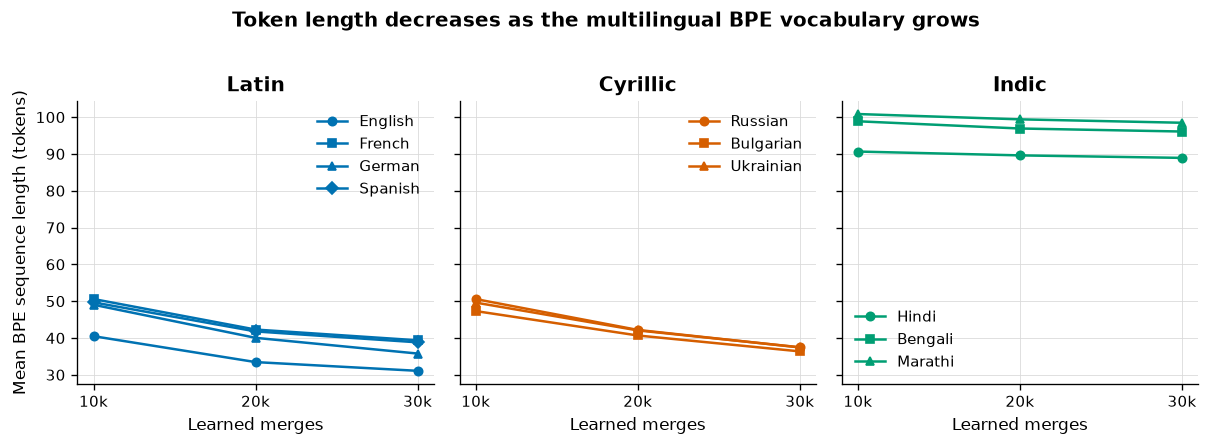

In [29]:
# Figure 1: shared-scale facets show the effect of increasing the merge budget.
language_to_family = {
    metadata["language"]: script_family(metadata["script"])
    for metadata in SELECTED_LANGUAGES.values()
}
MARKERS = ["o", "s", "^", "D"]
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.6), sharex=True, sharey=True)

for ax, family in zip(axes, ("Latin", "Cyrillic", "Indic")):
    family_languages = [
        language for language, language_family in language_to_family.items()
        if language_family == family
    ]
    for marker, language in zip(MARKERS, family_languages):
        plot_data = language_summary[language_summary["language"] == language]
        ax.plot(
            plot_data["num_merges"],
            plot_data["mean_custom_bpe_tokens"],
            color=SCRIPT_COLORS[family],
            marker=marker,
            linewidth=1.5,
            markersize=5,
            label=language,
        )
    ax.set_title(family, fontweight="bold")
    ax.set_xticks(available_checkpoints, [f"{value // 1000}k" for value in available_checkpoints])
    ax.set_xlabel("Learned merges")
    ax.grid(color="#D9D9D9", linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="best")

axes[0].set_ylabel("Mean BPE sequence length (tokens)")
fig.suptitle("Token length decreases as the multilingual BPE vocabulary grows", fontweight="bold", y=1.02)
finish_figure(fig, "bpe_merge_budget_scaling")

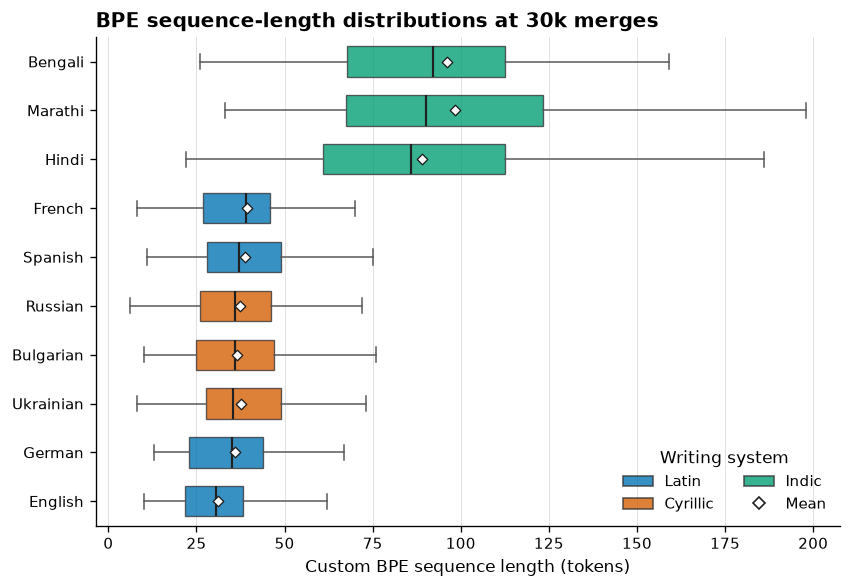

In [30]:
# Figure 2: full distributions at the largest, most practical checkpoint.
largest_checkpoint = available_checkpoints[-1]
largest_lengths = lengths_df[lengths_df["num_merges"] == largest_checkpoint]
language_order = largest_lengths.groupby("language")["custom_bpe_token_count"].median().sort_values().index.tolist()
box_data = [
    largest_lengths.loc[largest_lengths["language"] == language, "custom_bpe_token_count"].to_numpy()
    for language in language_order
]

fig, ax = plt.subplots(figsize=(7.2, 5.0))
boxplot = ax.boxplot(
    box_data, orientation="horizontal", tick_labels=language_order,
    widths=0.62, patch_artist=True, showfliers=False,
    medianprops={"color": "#202020", "linewidth": 1.3},
    whiskerprops={"color": "#555555", "linewidth": 0.9},
    capprops={"color": "#555555", "linewidth": 0.9},
)
for box, language in zip(boxplot["boxes"], language_order):
    box.set_facecolor(SCRIPT_COLORS[language_to_family[language]])
    box.set_alpha(0.78)
    box.set_edgecolor("#333333")
    box.set_linewidth(0.8)

means = [values.mean() for values in box_data]
ax.scatter(means, np.arange(1, len(language_order) + 1), marker="D", s=20,
           facecolor="white", edgecolor="#202020", linewidth=0.8, zorder=3)
ax.set_title(f"BPE sequence-length distributions at {largest_checkpoint // 1000}k merges", loc="left", fontweight="bold")
ax.set(xlabel="Custom BPE sequence length (tokens)", ylabel="")
ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
legend_handles = [
    Patch(facecolor=color, edgecolor="#333333", alpha=0.78, label=script)
    for script, color in SCRIPT_COLORS.items()
] + [plt.Line2D([], [], marker="D", linestyle="None", markersize=5,
                markerfacecolor="white", markeredgecolor="#202020", label="Mean")]
ax.legend(handles=legend_handles, title="Writing system", frameon=False, ncol=2, loc="lower right")
finish_figure(fig, "bpe_token_length_distributions_30k")

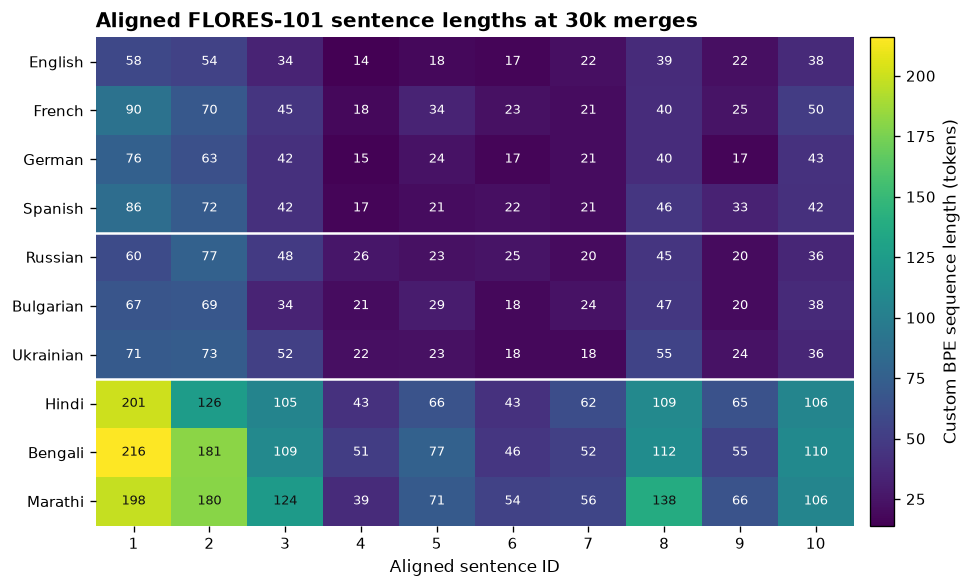

In [31]:
# Figure 3: aligned comparison at the largest checkpoint.
heatmap_language_order = [
    metadata["language"]
    for family in ("Latin", "Cyrillic", "Indic")
    for metadata in SELECTED_LANGUAGES.values()
    if script_family(metadata["script"]) == family
]
heatmap_data = first_ten_custom_lengths.loc[largest_checkpoint, heatmap_language_order].T
values = heatmap_data.to_numpy()

fig, ax = plt.subplots(figsize=(8.2, 5.0))
image = ax.imshow(values, cmap="viridis", aspect="auto", interpolation="nearest")
ax.set_title(f"Aligned FLORES-101 sentence lengths at {largest_checkpoint // 1000}k merges", loc="left", fontweight="bold")
ax.set_xlabel("Aligned sentence ID")
ax.set_ylabel("")
ax.set_xticks(np.arange(values.shape[1]), labels=heatmap_data.columns.astype(str))
ax.set_yticks(np.arange(values.shape[0]), labels=heatmap_data.index)

threshold = (values.min() + values.max()) / 2
for row in range(values.shape[0]):
    for column in range(values.shape[1]):
        ax.text(column, row, f"{values[row, column]:.0f}", ha="center", va="center",
                fontsize=7.5, color="white" if values[row, column] < threshold else "#111111")

# Thin separators retain script groupings without adding visual clutter.
ax.axhline(3.5, color="white", linewidth=1.5)
ax.axhline(6.5, color="white", linewidth=1.5)
colorbar = fig.colorbar(image, ax=ax, pad=0.02, fraction=0.04)
colorbar.set_label("Custom BPE sequence length (tokens)")
for spine in ax.spines.values():
    spine.set_visible(False)
finish_figure(fig, "bpe_aligned_sentence_heatmap_30k")